# This notebook study the consistency of kNN after downsampling

### Utilities (define key variables; load packages)

In [182]:
from pathlib import Path
from sklearn.manifold import SpectralEmbedding
from umap.umap_ import nearest_neighbors
from sklearn.utils import check_random_state
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import Colormap
import itertools
import pandas as pd
import numpy as np
import random

project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "umap_embedding": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "outdir": base / "notebooks/inter-cluster-angle/temp/results_20260123/{sample}"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

# hyperparameters
metrics = ["cosine", "correlation", "euclidean"]
n_neighbors = [10, 30, 50, 100, 200]

# seeds
random.seed(42)
seeds = random.sample(range(10**4, 10**5 -1), 20)

# samples
samples = ["zma", "zma-5k", "zma-1k"]

Read PCA embeddings

In [183]:
pca_embeddings = {}
for sample in samples:
    pca_embeddings[sample] = pd.read_csv(paths.pca(sample=sample), index_col=0)

## Compare overlap of kNN across metrics x n_neighbors

In [184]:
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)
    
def knn_jaccard(graph1, graph2):
    jaccard_indices = []
    for i in range(graph1[0].shape[0]):
        jaccard_indices.append(
            jaccard(
                set(graph1[0][i][1:]),
                set(graph2[0][i][1:])
            )
        )
    return jaccard_indices

In [185]:
knn_graphs = {} # key: tuple of (sample, metric, n_neighbors, seed); value: [neighbors, dist]
for comb in itertools.product(samples, metrics, n_neighbors, seeds):
    sample, metric, nn, seed = comb
    random_state = check_random_state(seed)
    knn_graphs[comb] = nearest_neighbors(
        pca_embeddings[sample].values,
        n_neighbors=nn,
        metric=metric,
        metric_kwds=None,
        angular=metric in (
            "cosine",
            "correlation",
            "dice",
            "jaccard",
            "ll_dirichlet",
            "hellinger"
        ),
        random_state=random_state,
        n_jobs=1,
        verbose=False
    )

Compare kNN overlaps between runs (the consistency of the approximated kNN)

In [196]:
for comb in itertools.product(samples, metrics, n_neighbors):
    print(comb)

('zma', 'cosine', 10)
('zma', 'cosine', 30)
('zma', 'cosine', 50)
('zma', 'cosine', 100)
('zma', 'cosine', 200)
('zma', 'correlation', 10)
('zma', 'correlation', 30)
('zma', 'correlation', 50)
('zma', 'correlation', 100)
('zma', 'correlation', 200)
('zma', 'euclidean', 10)
('zma', 'euclidean', 30)
('zma', 'euclidean', 50)
('zma', 'euclidean', 100)
('zma', 'euclidean', 200)
('zma-5k', 'cosine', 10)
('zma-5k', 'cosine', 30)
('zma-5k', 'cosine', 50)
('zma-5k', 'cosine', 100)
('zma-5k', 'cosine', 200)
('zma-5k', 'correlation', 10)
('zma-5k', 'correlation', 30)
('zma-5k', 'correlation', 50)
('zma-5k', 'correlation', 100)
('zma-5k', 'correlation', 200)
('zma-5k', 'euclidean', 10)
('zma-5k', 'euclidean', 30)
('zma-5k', 'euclidean', 50)
('zma-5k', 'euclidean', 100)
('zma-5k', 'euclidean', 200)
('zma-1k', 'cosine', 10)
('zma-1k', 'cosine', 30)
('zma-1k', 'cosine', 50)
('zma-1k', 'cosine', 100)
('zma-1k', 'cosine', 200)
('zma-1k', 'correlation', 10)
('zma-1k', 'correlation', 30)
('zma-1k', 'corr

In [201]:
jaccard_dfs = []
for pairs in [i for i in itertools.pairwise(seeds)]:
    s1, s2 = pairs
    for comb in itertools.product(samples, metrics, n_neighbors):
        s, metric, nn = comb
        jaccard_indices = knn_jaccard(
            knn_graphs[(*comb, s1)],
            knn_graphs[(*comb, s2)]
        )
        jaccard_df = pd.DataFrame({
            "pairs": " x ".join([str(i) for i in pairs]),
            "metric": metric,
            "n_neighbors": nn,
            "sample": s,
            "barcode": pca_embeddings["zma"].index,
            "jaccard": jaccard_indices
        })
        jaccard_dfs.append(jaccard_df)

In [203]:
data = pd.concat(jaccard_dfs)
print(data.shape)
data.head()

(5385645, 6)


,pairs,metric,n_neighbors,sample,barcode,jaccard
0,93810 x 24592,cosine,10,zma,E1_e1_1_X262565,1.0
1,93810 x 24592,cosine,10,zma,E1_e1_1_X335878,1.0
2,93810 x 24592,cosine,10,zma,E1_e1_1_X364224,1.0
3,93810 x 24592,cosine,10,zma,E1_e1_1_X247820,1.0
4,93810 x 24592,cosine,10,zma,E1_e1_1_X193446,1.0


In [207]:
foo = data.groupby(["sample", "metric", "n_neighbors", "barcode"]).agg({
    "jaccard": "mean",
})
foo = foo.reset_index()
foo.head()

,sample,metric,n_neighbors,barcode,jaccard
0,zma,correlation,10,E1_e1_1_X100270,1.0
1,zma,correlation,10,E1_e1_1_X100420,1.0
2,zma,correlation,10,E1_e1_1_X100828,1.0
3,zma,correlation,10,E1_e1_1_X100936,1.0
4,zma,correlation,10,E1_e1_1_X101018,1.0


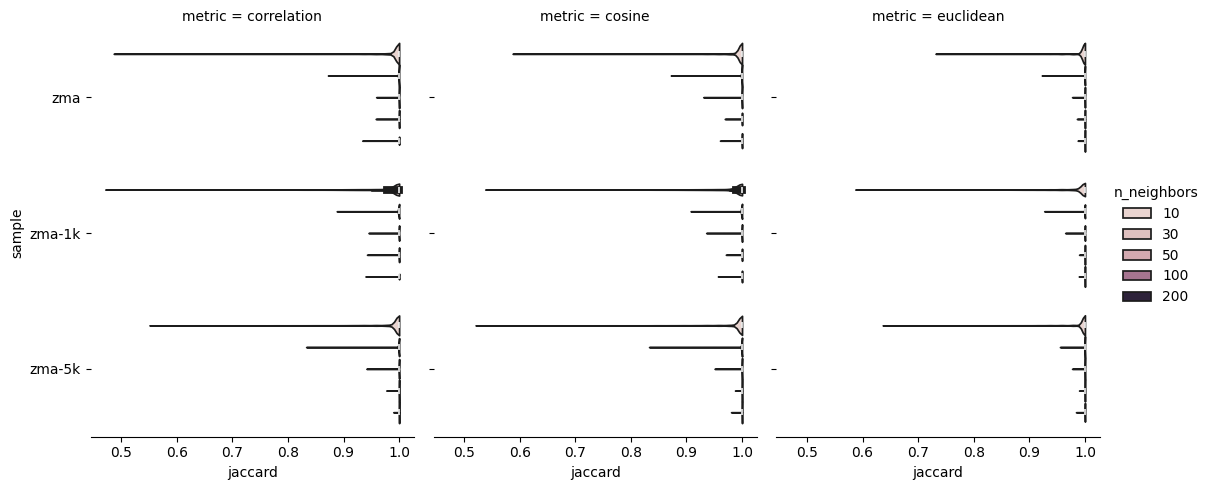

In [210]:
g = sns.catplot(
    data=foo, x="jaccard", y="sample", hue="n_neighbors", col="metric",
    kind="violin", aspect=.75, dodge=True, cut=0
)
g.despine(left=True)
g.savefig("nn_jaccard_downsampled_self.svg")

Compare kNN overlap between zma vs. zma-5k, zma vs. zma-1k

In [186]:
jaccard_dfs = []
for pairs in [("zma", "zma-5k"), ("zma", "zma-1k")]:
    s1, s2 = pairs
    for comb in itertools.product(metrics, n_neighbors, seeds):
        metric, nn, seed = comb
        jaccard_indices = knn_jaccard(
            knn_graphs[(s1, *comb)],
            knn_graphs[(s2, *comb)]
        )
        jaccard_df = pd.DataFrame({
            "pairs": " x ".join(pairs),
            "metric": metric,
            "n_neighbors": nn,
            "seed": seed,
            "barcode": pca_embeddings["zma"].index,
            "jaccard": jaccard_indices
        })
        jaccard_dfs.append(jaccard_df)

In [187]:
data = pd.concat(jaccard_dfs)
print(data.shape)
data.head()

(3779400, 6)


,pairs,metric,n_neighbors,seed,barcode,jaccard
0,zma x zma-5k,cosine,10,93810,E1_e1_1_X262565,0.636364
1,zma x zma-5k,cosine,10,93810,E1_e1_1_X335878,0.800000
2,zma x zma-5k,cosine,10,93810,E1_e1_1_X364224,0.500000
3,zma x zma-5k,cosine,10,93810,E1_e1_1_X247820,1.000000
4,zma x zma-5k,cosine,10,93810,E1_e1_1_X193446,0.500000


In [188]:
foo = data.groupby(["pairs", "metric", "n_neighbors", "barcode"]).mean()
foo = foo.reset_index()

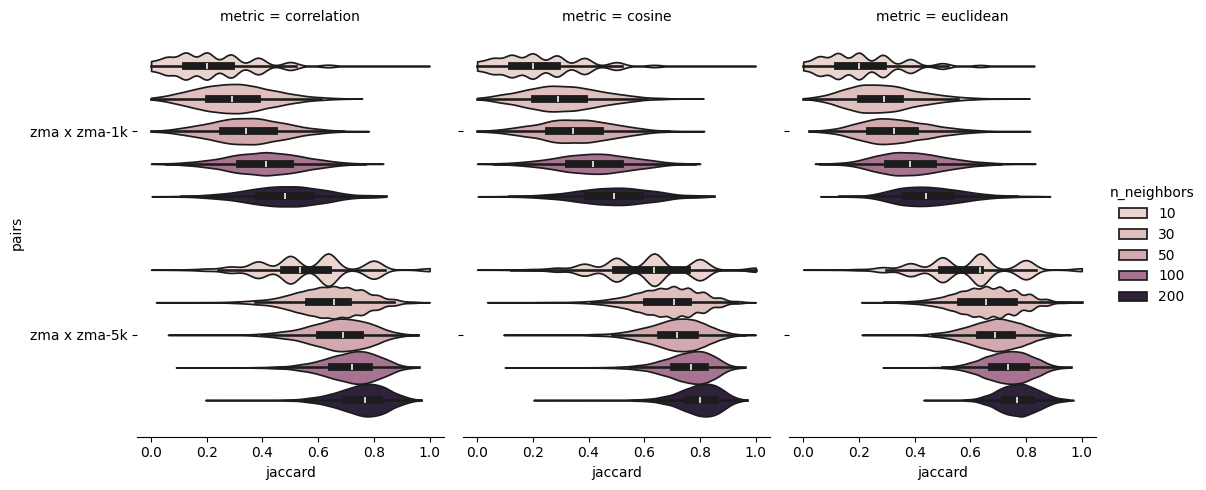

In [189]:
g = sns.catplot(
    data=foo, x="jaccard", y="pairs", hue="n_neighbors", col="metric",
    kind="violin", aspect=.75, dodge=True, cut=0
)
g.despine(left=True)
g.savefig("nn_jaccard_downsampled.svg")